DATASET DESCRIPTION
Dataset shape: 11000 rows, 19 columns
Column names: ['Age', 'Gender', 'Occupation', 'Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)', 'Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness', 'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event', 'Diet Quality (1-10)', 'Anxiety Level (1-10)']
Data types:
Age                                    int64
Gender                                object
Occupation                            object
Sleep Hours                          float64
Physical Activity (hrs/week)         float64
Caffeine Intake (mg/day)               int64
Alcohol Consumption (drinks/week)      int64
Smoking                               object
Family History of Anxiety             object
Stress Level (1-10)                    int64
Heart Rate (bpm)                       int64
Breat

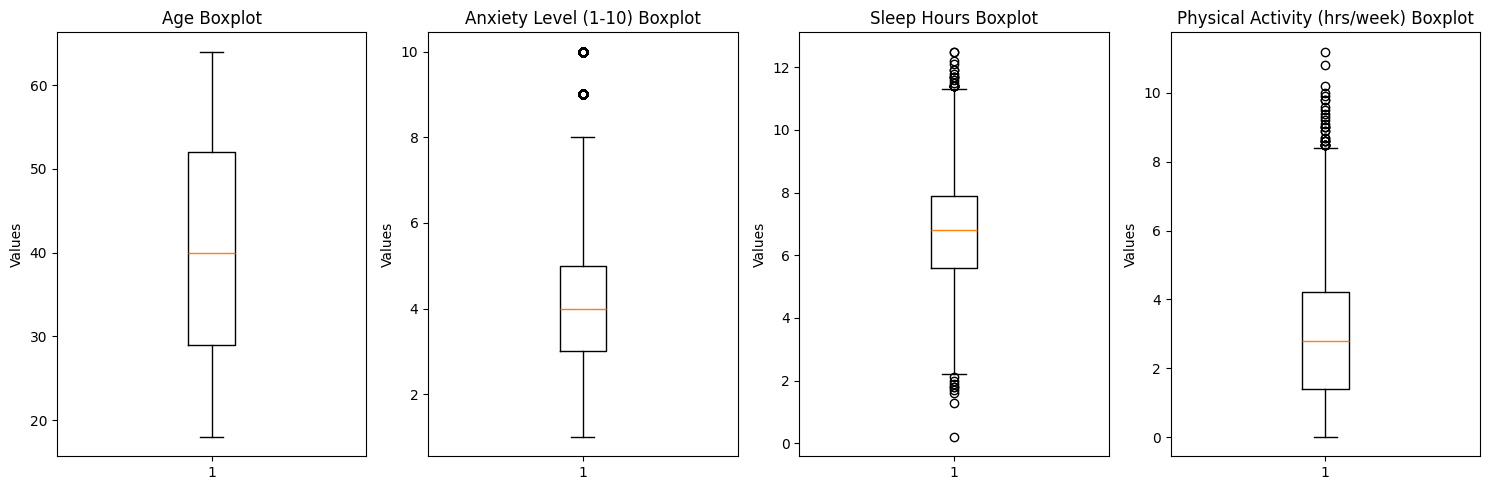

HIGH CORRELATIONS ABS > 0.2
                   Feature 1            Feature 2  Correlation
         Stress Level (1-10) Anxiety Level (1-10)     0.699490
    Caffeine Intake (mg/day) Anxiety Level (1-10)     0.256051
Therapy Sessions (per month) Anxiety Level (1-10)     0.240451
                 Sleep Hours Anxiety Level (1-10)    -0.401197


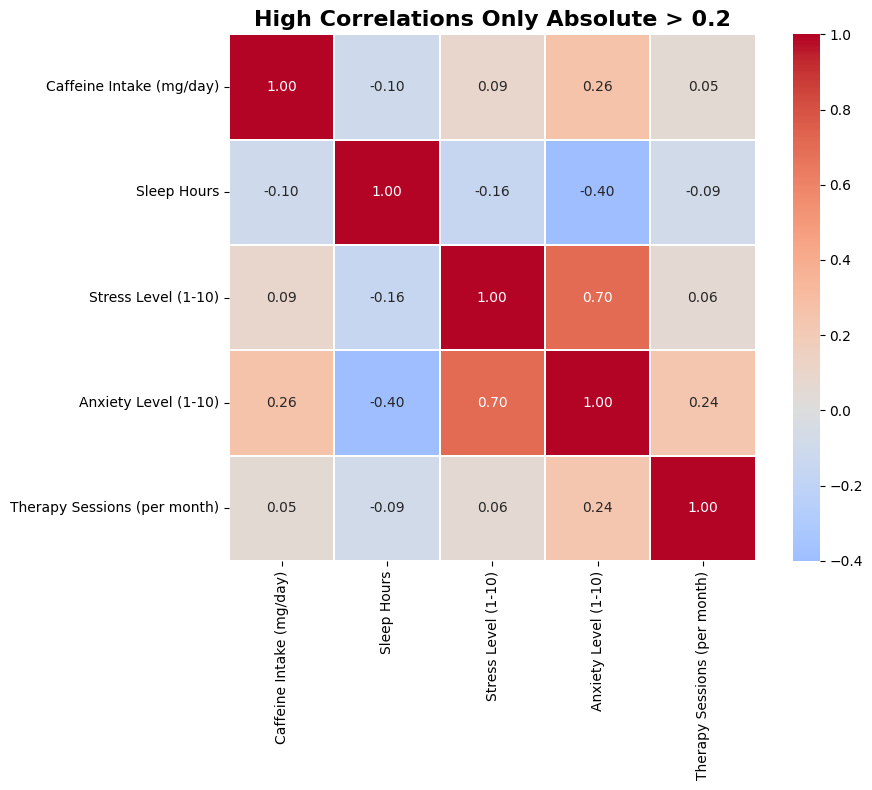

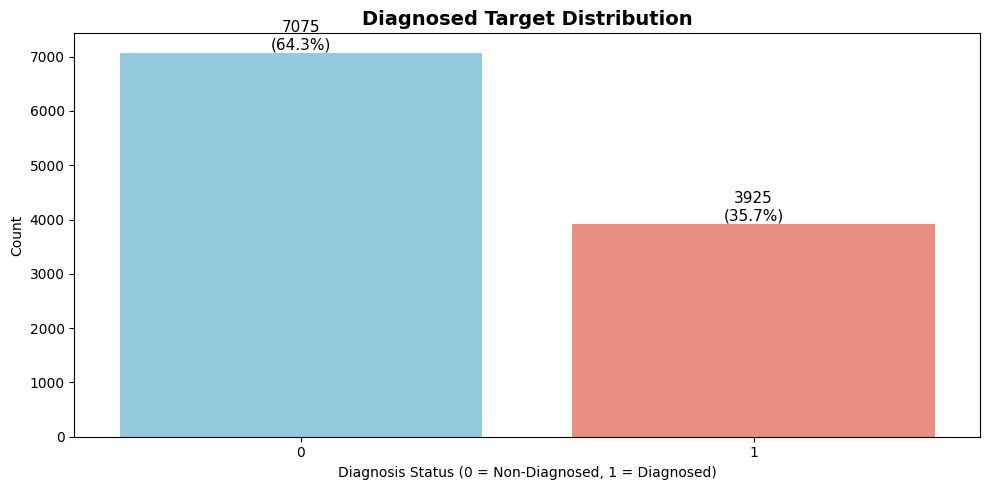

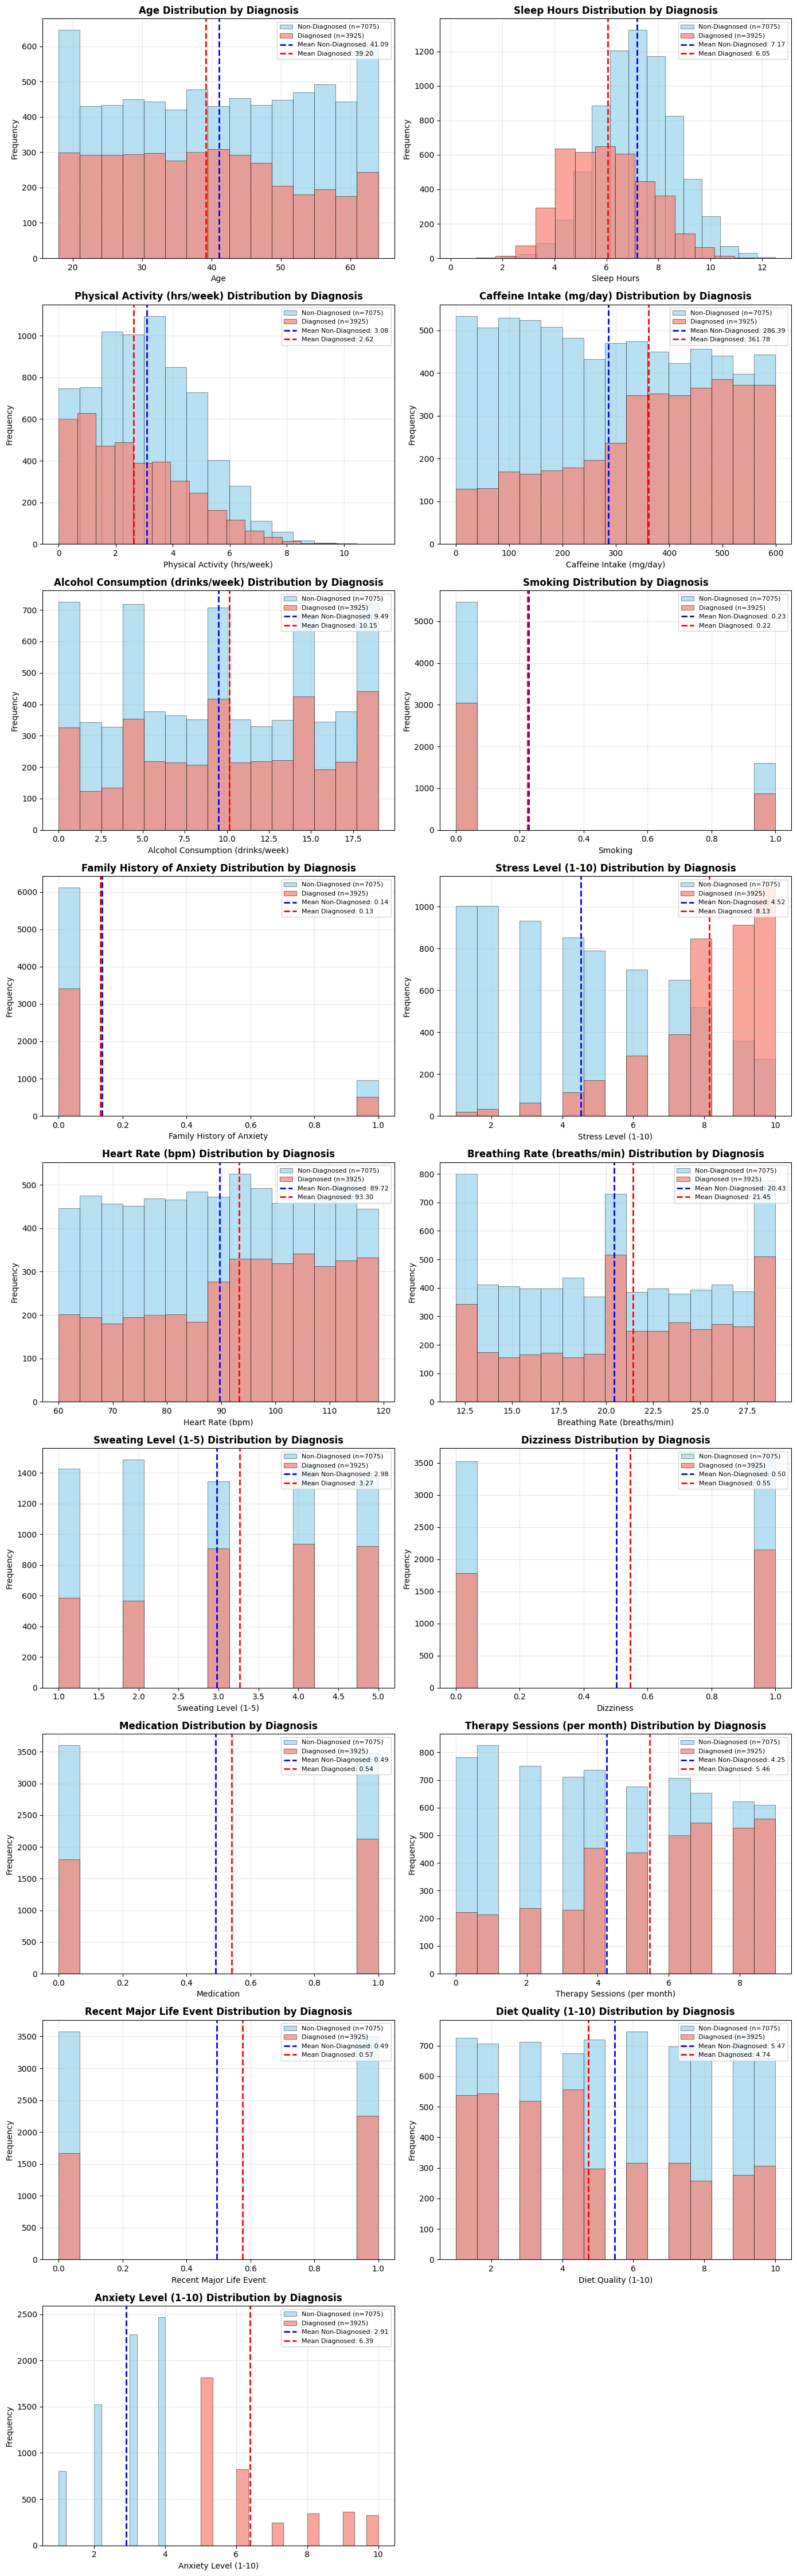

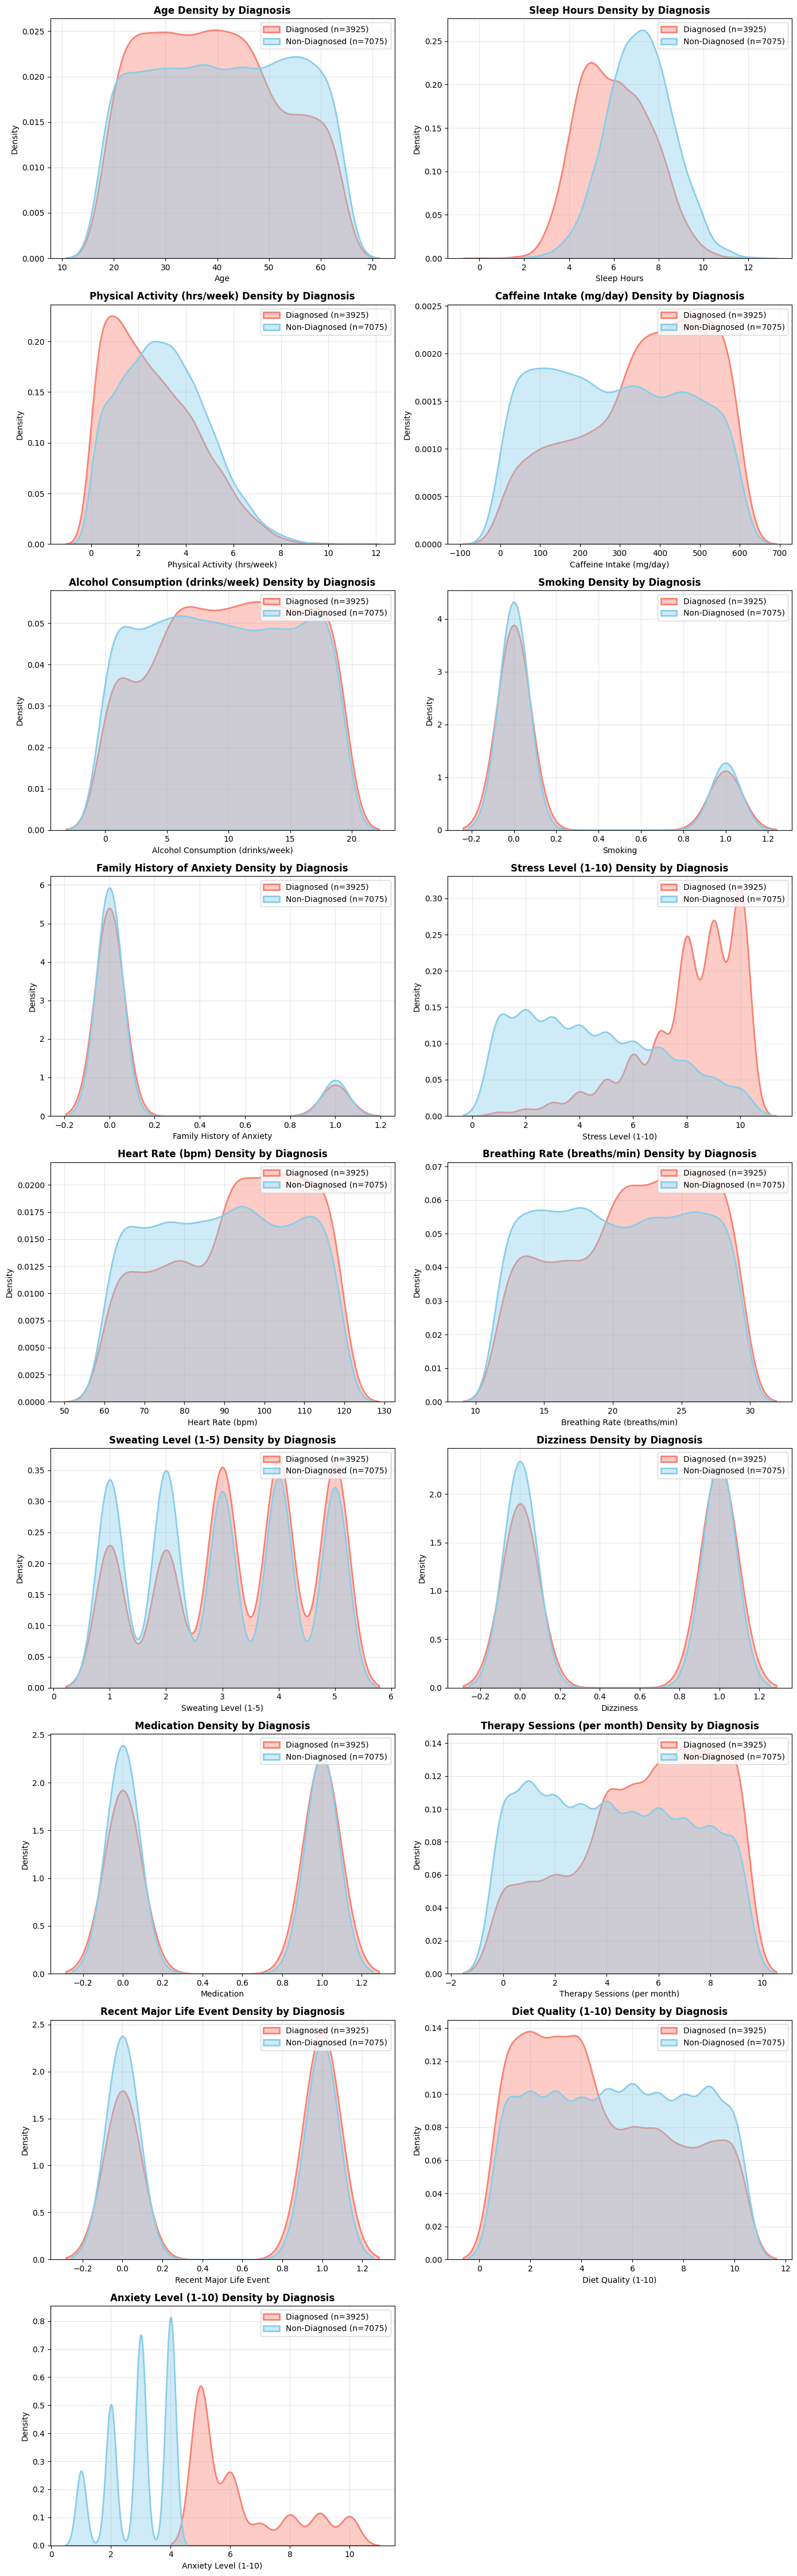

SKEWNESS AND KURTOSIS OF FEATURES
                                   Skewness  Kurtosis
Family History of Anxiety          2.154874  2.643963
Smoking                            1.308571 -0.287695
Anxiety Level (1-10)               0.918902  0.662642
Physical Activity (hrs/week)       0.490496 -0.272559
Stress Level (1-10)               -0.148151 -1.273465
Diet Quality (1-10)                0.139806 -1.217157
Heart Rate (bpm)                  -0.128128 -1.157126
Caffeine Intake (mg/day)          -0.115152 -1.186871
Therapy Sessions (per month)      -0.099686 -1.192781
Recent Major Life Event           -0.091380 -1.992012
Breathing Rate (breaths/min)      -0.090613 -1.199353
Sweating Level (1-5)              -0.088569 -1.269781
Dizziness                         -0.071692 -1.995223
Age                                0.061239 -1.156933
Alcohol Consumption (drinks/week) -0.040870 -1.176549
Medication                        -0.035283 -1.999119
Sleep Hours                       -0.011845 -0.2

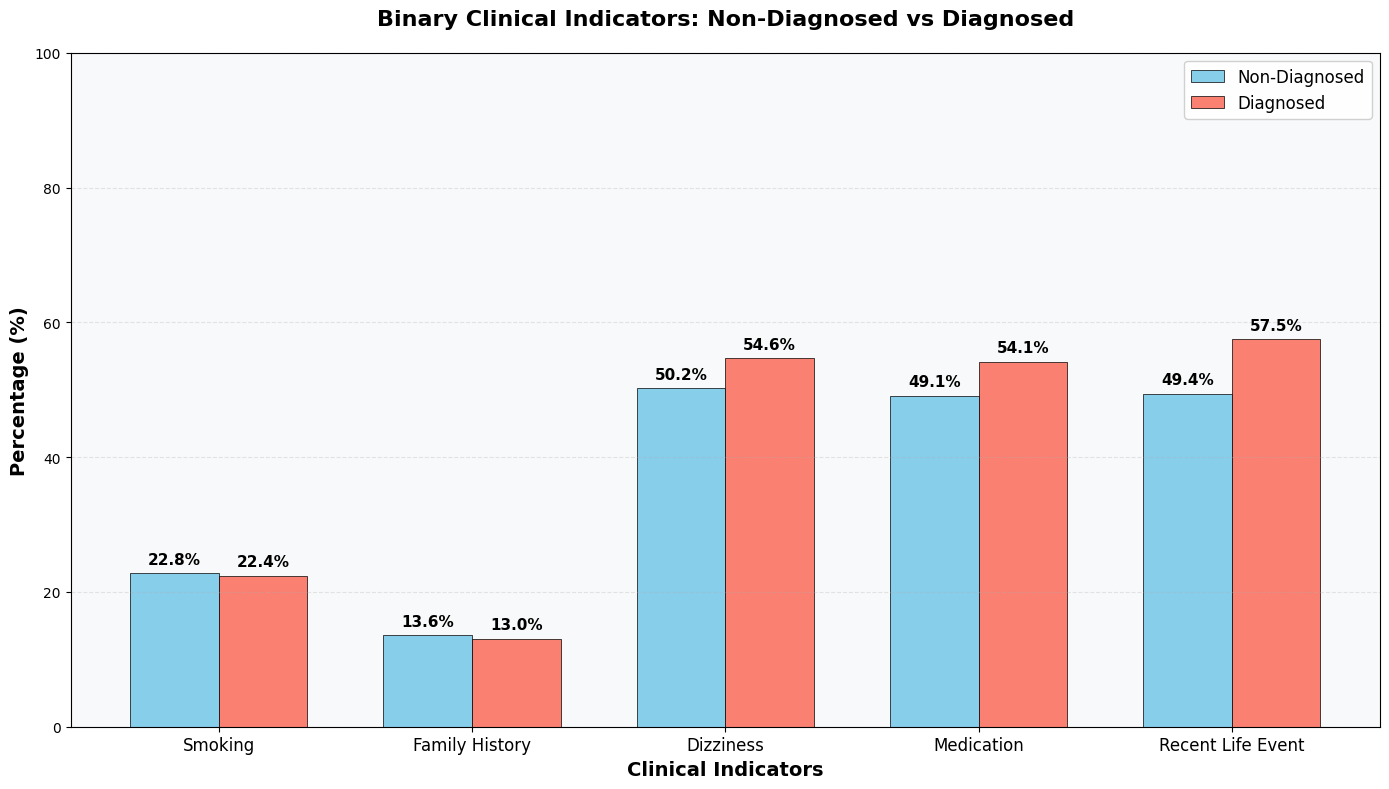


Binary Features - Percentageby Diagnosis Group:
------------------------------------------------------------
Smoking              Non-Diagnosed: 22.8%  |  Diagnosed: 22.4%  |  Difference: -0.4%
Family History       Non-Diagnosed: 13.6%  |  Diagnosed: 13.0%  |  Difference: -0.6%
Dizziness            Non-Diagnosed: 50.2%  |  Diagnosed: 54.6%  |  Difference: 4.4%
Medication           Non-Diagnosed: 49.1%  |  Diagnosed: 54.1%  |  Difference: 5.0%
Recent Life Event    Non-Diagnosed: 49.4%  |  Diagnosed: 57.5%  |  Difference: 8.1%

Dataset saved
Final dataset shape: 11000 rows, 20 columns


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
data = pd.read_csv("datasets/family_anxiety_14_dataset.csv") # training dataset
# data = pd.read_csv("datasets/enhanced_anxiety_dataset.csv") # testing dataset

# Display basic dataset information
print("DATASET DESCRIPTION")
print(f"Dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Column names: {list(data.columns)}")
print(f"Data types:\n{data.dtypes}")
print(f"Missing values:\n{data.isnull().sum()}")

# Convert Yes/No columns to binary using map() instead of replace to avoid warning
yes_no_cols = ['Smoking', 'Family History of Anxiety', 'Dizziness', 
               'Medication', 'Recent Major Life Event']
for col in yes_no_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

# Creating target column: Diagnosed if Anxiety Level > 4
data['Diagnosed'] = (data['Anxiety Level (1-10)'] > 4).astype(int)

print("NEW TARGET COLUMN DIAGNOSED")
print(data[['Anxiety Level (1-10)', 'Diagnosed']].head())
print(f"Diagnosed distribution: 0 = {sum(data['Diagnosed']==0)}, 1 = {sum(data['Diagnosed']==1)}")

# Features vs target
features = data.drop(columns=['Diagnosed'])
target = data['Diagnosed']

# Display min and max for numeric features after conversion
numeric_features = features.select_dtypes(include=[np.number])

print("NUMERIC FEATURES MIN AND MAX VALUES")
for col in numeric_features.columns:
    print(f"{col}: Min = {numeric_features[col].min()}, Max = {numeric_features[col].max()}")
    
# statistical summary
print("STATISTICAL SUMMARY OF NUMERIC FEATURES")
print(numeric_features.describe())

# OUTLIER DETECTION FOR CONTINUOUS COLUMNS
print("OUTLIER DETECTION FOR CONTINUOUS COLUMNS")

# Identify continuous columns
continuous_cols = ['Age', 'Anxiety Level (1-10)', 'Sleep Hours', 'Physical Activity (hrs/week)']

print(f"Continuous columns: {continuous_cols}")

# IQR Method for outlier detection
def detect_outliers_iqr(data, columns):
    outlier_summary = {}
    
    for col in columns:
        if col in data.columns:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
            outlier_indices = outliers.index.tolist()
            
            outlier_summary[col] = {
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'outlier_count': len(outliers),
                'outlier_percentage': (len(outliers) / len(data)) * 100,
                'outlier_indices': outlier_indices,
                'outlier_values': outliers[col].tolist()
            }
    
    return outlier_summary

# Z-Score Method for outlier detection
def detect_outliers_zscore(data, columns, threshold=3):
    outlier_summary = {}
    
    for col in columns:
        if col in data.columns:
            mean = data[col].mean()
            std = data[col].std()
            z_scores = np.abs((data[col] - mean) / std)
            
            outliers = data[z_scores > threshold]
            outlier_indices = outliers.index.tolist()
            
            outlier_summary[col] = {
                'mean': mean,
                'std': std,
                'threshold': threshold,
                'outlier_count': len(outliers),
                'outlier_percentage': (len(outliers) / len(data)) * 100,
                'outlier_indices': outlier_indices,
                'outlier_values': outliers[col].tolist(),
                'max_zscore': z_scores.max()
            }
    
    return outlier_summary

# Detect outliers using both methods
iqr_outliers = detect_outliers_iqr(data, continuous_cols)
zscore_outliers = detect_outliers_zscore(data, continuous_cols)

# Display IQR method results
print("IQR METHOD OUTLIER RESULTS")
for col, stats in iqr_outliers.items():
    print(f"{col}: {stats['outlier_count']} outliers ({stats['outlier_percentage']:.2f}%)")
    print(f"  Bounds: [{stats['lower_bound']:.2f}, {stats['upper_bound']:.2f}]")
    if stats['outlier_count'] > 0:
        print(f"  Outlier values: {stats['outlier_values']}")

# Display Z-Score method results
print("ZSCORE METHOD OUTLIER RESULTS")
for col, stats in zscore_outliers.items():
    print(f"{col}: {stats['outlier_count']} outliers ({stats['outlier_percentage']:.2f}%)")
    print(f"  Max ZScore: {stats['max_zscore']:.2f}")
    if stats['outlier_count'] > 0:
        print(f"  Outlier values: {stats['outlier_values']}")

# Box plots for visualizing outliers
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(15, 5))
if len(continuous_cols) == 1:
    axes = [axes]

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(f'{col} Boxplot')
    axes[i].set_ylabel('Values')
plt.tight_layout()
plt.show()

# Numeric features correlation heatmap showing only high correlations
print("HIGH CORRELATIONS ABS > 0.2")
corr_matrix = numeric_features.corr(method='spearman')

# Create a mask for correlations with absolute value > 0.2
mask = np.abs(corr_matrix) > 0.2

# Remove diagonal
np.fill_diagonal(mask.values, False)

# Get pairs with high correlation
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if mask.iloc[i, j]:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

# Display high correlation pairs
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df = high_corr_df.sort_values('Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No correlations with absolute value > 0.2 found")

# Create heatmap only for high correlations
if high_corr_pairs:
    plt.figure(figsize=(10, 8))
    
    # Get unique features from high correlation pairs
    high_corr_features = list(set([item['Feature 1'] for item in high_corr_pairs] + 
                                  [item['Feature 2'] for item in high_corr_pairs]))
    
    # Filter correlation matrix for these features
    high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
    
    sns.heatmap(high_corr_matrix, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, linewidths=0.2, square=True)
    plt.title("High Correlations Only Absolute > 0.2", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# 1. ENHANCED TARGET DISTRIBUTION PLOT - with percentages and clear labels
plt.figure(figsize=(10, 5))
ax = sns.countplot(x=data['Diagnosed'], hue=data['Diagnosed'], 
                   palette=['skyblue', 'salmon'], legend=False)
plt.title("Diagnosed Target Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Diagnosis Status (0 = Non-Diagnosed, 1 = Diagnosed)")
plt.ylabel("Count")

# Add count and percentage labels on bars
total = len(data)
for p in ax.patches:
    count = int(p.get_height())
    percentage = count/total*100
    ax.annotate(f'{count}\n({percentage:.1f}%)', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# 2. OVERLAYED HISTOGRAMS - diagnosed vs non-diagnosed with mean lines
numeric_cols = numeric_features.columns.tolist()
n_cols = len(numeric_cols)
n_rows = (n_cols + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Getting data for diagnosed and non-diagnosed separately
    diagnosed_data = data[data['Diagnosed'] == 1][col]
    nondiagnosed_data = data[data['Diagnosed'] == 0][col]
    
    # Plotting histograms with transparency
    ax.hist(nondiagnosed_data, bins=15, alpha=0.6, color='skyblue', 
            label=f'Non-Diagnosed (n={len(nondiagnosed_data)})', edgecolor='black', linewidth=0.5)
    ax.hist(diagnosed_data, bins=15, alpha=0.7, color='salmon', 
            label=f'Diagnosed (n={len(diagnosed_data)})', edgecolor='black', linewidth=0.5)
    
    # Adding vertical lines for means
    ax.axvline(nondiagnosed_data.mean(), color='blue', linestyle='--', 
               linewidth=2, label=f'Mean Non-Diagnosed: {nondiagnosed_data.mean():.2f}')
    ax.axvline(diagnosed_data.mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean Diagnosed: {diagnosed_data.mean():.2f}')
    
    ax.set_title(f'{col} Distribution by Diagnosis', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 3. DENSITY PLOTS 
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # Create density plots for each group
    for diagnosis, color, label in [(1, 'salmon', 'Diagnosed'), (0, 'skyblue', 'Non-Diagnosed')]:
        subset = data[data['Diagnosed'] == diagnosis]
        sns.kdeplot(data=subset, x=col, ax=ax, color=color, 
                    label=f'{label} (n={len(subset)})', 
                    fill=True, alpha=0.4, linewidth=2)
    
    ax.set_title(f'{col} Density by Diagnosis', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


# Skewness and kurtosis for numeric features
skew_kurt = pd.DataFrame({
    'Skewness': numeric_features.skew(),
    'Kurtosis': numeric_features.kurtosis()
}).sort_values(by='Skewness', key=abs, ascending=False)

print("SKEWNESS AND KURTOSIS OF FEATURES")
print(skew_kurt)

# Categorical features summary
categorical_features = features.select_dtypes(include=['object', 'category']).columns

print("CATEGORICAL FEATURES SUMMARY")
for col in categorical_features:
    print(f"Categorical Feature: {col}")
    print(f"Number of unique values: {data[col].nunique()}")
    print("Value counts top 10:")
    print(data[col].value_counts().head(10))

# 4. PAIRED BAR CHART FOR BINARY FEATURES
print("\n" + "="*60)
print("BINARY FEATURES PERCENTAGES BY DIAGNOSIS GROUP")
print("="*60)

# Calculate percentages from your actual data
binary_cols = ['Smoking', 'Family History of Anxiety', 'Dizziness', 
               'Medication', 'Recent Major Life Event']

# Feature names for display (cleaner labels)
feature_display_names = ['Smoking', 'Family History', 'Dizziness', 
                         'Medication', 'Recent Life Event']

# Calculate percentages from the actual dataset
non_diagnosed_pcts = []
diagnosed_pcts = []

for col in binary_cols:
    diag_1_pct = data[data['Diagnosed'] == 1][col].mean() * 100
    diag_0_pct = data[data['Diagnosed'] == 0][col].mean() * 100
    non_diagnosed_pcts.append(diag_0_pct)
    diagnosed_pcts.append(diag_1_pct)

# Create the Paired Bar Chart
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(feature_display_names))
width = 0.35

bars1 = ax.bar(x - width/2, non_diagnosed_pcts, width, 
               label='Non-Diagnosed', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, diagnosed_pcts, width, 
               label='Diagnosed', color='salmon', edgecolor='black', linewidth=0.5)

# Customize chart
ax.set_xlabel('Clinical Indicators', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Binary Clinical Indicators: Non-Diagnosed vs Diagnosed', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(feature_display_names, fontsize=12)
ax.legend(loc='upper right', fontsize=12, framealpha=0.9)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', 
                fontsize=11, fontweight='bold')

# Add a subtle background color for better readability
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

# Print the percentages for reference
print("\nBinary Features - Percentageby Diagnosis Group:")
print("-" * 60)
for i, feature in enumerate(feature_display_names):
    print(f"{feature:20} Non-Diagnosed: {non_diagnosed_pcts[i]:.1f}%  |  Diagnosed: {diagnosed_pcts[i]:.1f}%  |  Difference: {diagnosed_pcts[i] - non_diagnosed_pcts[i]:.1f}%")

# Save cleaned dataset
data.to_csv("training_dataset.csv", index=False) # save the trainig dataset
# data.to_csv("testing_dataset.csv", index=False)
print("\n" + "="*60)
print("Dataset saved")
print(f"Final dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")